<a href="https://colab.research.google.com/github/maria-sedo/Semantic-book-recommender-in-Catalan/blob/main/Semantic_book_recommender_in_Catalan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install sentence-transformers #library to generate embeddings (numerical representations of text)
!pip install spacy #library for language processing
!python -m spacy download ca_core_news_sm
!pip install stopwordsiso #library to obtain stopword lists

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 60.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ca_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [18]:
#Import libraries
import pandas as pd                #to manipulate dataframes
import matplotlib.pyplot as plt    #for data visualization
import seaborn as sns              #for data visualization

from sentence_transformers import SentenceTransformer, util  #for embeddings and similarity computation
model = SentenceTransformer("projecte-aina/st-nli-ca_paraphrase-multilingual-mpnet-base") #to load the SentenceTransformer model than supports Catalan

import spacy  #library for language processing
nlp = spacy.load("ca_core_news_sm")

import stopwordsiso as stopwords  #to obtain stopwords lists
stop_words = stopwords.stopwords("ca") #to load the Catalan stopwords

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

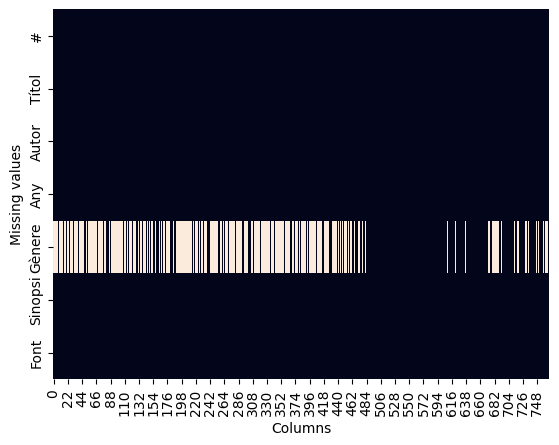

In [19]:
# Data exploration: create a missingness heatmap

books = pd.read_excel("catalan_books.xlsx") # To read the excel file with the books

ax = plt.axes()   #to create a plot
sns.heatmap(books.isna().transpose(), cbar=False, ax=ax)  #to create a seaborn heatmap that documents the missing values in the dataset

plt.xlabel("Columns")         #to add labels to the plot
plt.ylabel("Missing values")
plt.show()                    #to display the plot


In [20]:
# Data exploration: check synopses' length (number of words)

books["words_in_synopsis"] = books["Sinopsi"].str.split().str.len() #to create a new category in the plot with the length of the synopses (number of words)
books.loc[books["words_in_synopsis"].between(0,24), "Sinopsi"] #to check the synopses that have less than 25 words (potentially too short)

,Sinopsi


In [21]:
# Data exploration: remove categories we are not going to use

books_cleaned = books.drop(["Gènere", "Font", "words_in_synopsis"], axis=1)
books_cleaned[529:549]   # an example from the dataset

,#,Títol,Autor,Any,Sinopsi
529,530,El diari d'Anna Frank,Anne Frank,1992,El diari d'una noia jueva amagada amb la seva ...
530,531,Orgull i prejudici,Jane Austen,2008,Elizabeth Bennet i el senyor Darcy superen l'o...
531,532,Seny i sentiment,Jane Austen,2012,Les germanes Dashwood —la racional Elinor i la...
532,533,Moby Dick,Herman Melville,2005,"El capità Ahab, obsessionat per la balena blan..."
533,534,El gran Gatsby,F. Scott Fitzgerald,2011,Jay Gatsby celebra festes opulentes a Long Isl...
534,535,Matar un rossinyol,Harper Lee,2015,"Scout Finch narra la defensa del seu pare, l'a..."
535,536,El vell i la mar,Ernest Hemingway,1997,Un pescador cubà solitari lluita durant tres d...
536,537,Les aventures d'Alícia al país de les meravelles,Lewis Carroll,1996,Alícia cau per un cau de conill i es troba en ...
537,538,L'estranger,Albert Camus,2001,"Meursault, un oficinista d'Alger, comet un ass..."
538,539,La pesta,Albert Camus,2003,Una epidèmia de pesta aïlla la ciutat d'Orà i ...


In [25]:
#User input
query = input("Benvingut al recomanador de llibres en català! Podries descriure com vols que sigui la teva pròxima lectura? (al voltant de 25 paraules): ")


Benvingut al recomanador de llibres en català! Podries descriure com vols que sigui la teva pròxima lectura? (al voltant de 25 paraules): Un noi descobreix que és mag i és admès a una escola de màgia. Viu moltes aventures amb els seus amics i sempre defensa el bé. Ha de lluitar contra un personatge molt dolent.


In [22]:
# Text-level embeddings (recommender)

texts = books_cleaned["Sinopsi"].tolist()   #it's important to have the texts in a list, for the embeddings
titles = books_cleaned["Títol"].tolist()    #it's important to have the titles of the books in a list, for the output

embeddings = model.encode(texts, show_progress_bar=True)   #to convert the synopses into a numerical vector (embedding) using the chosen model. A bar with the progress will appear
query_embedding = model.encode(query)   #to convert the user input into a numerical vector (embedding) that represents its meaning

scores = util.cos_sim(query_embedding, embeddings)[0] #to compute cosine similarity between the user input embedding and the embeddings of all the synopses (how similar they are in meaning)

top_results = scores.argsort(descending=True) [:5]    #to sort the books by similarity score (highest first) and select the most similar ones (top 5)


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

In [23]:
# The output of the recommender: books's title, synopses, similarity scores and similar words between the user's input and the books' synopses

# 1. To prepare the words of the query (tokenization, lemmatizing, lowercasing; removing particles and stopwords) (word-level analysis)

query_words = []            #a list to store the words of the query without stopwords and particles

doc = nlp(query.lower())    #to process the query with spacy, and lowercase the query

for token in doc:
  lemma = token.lemma_             #to get the base form of the words
  if lemma not in {"l", "d", "s"}: #if the word is not one of these particles...(to remove the Catalan particles that resulted from tokenization)
    if lemma not in stop_words:    #if the word is not a stopword...
      if token.is_alpha or token.like_num:   #to keep alphanumerical tokens
       query_words.append(lemma)             #add the word to the list

# 2. To convert the words of the user's input into numerical vectors (embeddings) that represents their meanings (word-level embeddings)
query_words_embedding = model.encode(query_words)

# 3. To store pairs of the word-level analysis for internal use (pairs and scores of recommended books)
internal_info = []

# 4. Loop for the recommended books

print("Aquí tens els llibres que et recomanem seguint la teva demanda. Hi trobaràs els títols, les sinopsis, les puntuacions de similitud (amb un màxim de 1.00, com més altes, més propers són els llibres a la teva descripció) i per què te'ls recomanem:", "\n")

for result in top_results: #loop trough top recommended books
  print(titles[result])    #to print the titles of the most similar books
  print("Sinopsi:", texts[result])     #to print the synopses of the most similar books
  print(f"Puntuació de semblança: {scores[result].item():.2f}")    #to print the similarity score between the user's input and the book's synopsis. .item() transforms the tensor into a float to allow formatting. The .2f is used to show only two numbers and interpret better the results

  #To prepare the words of the synopses (tokenization, lemmatizing, lowercasing; removing particles and stopwords) (word-level analysis)

  synopses_words = []         #a list to store the words of the synopses without stopwords and particles

  doc = nlp(texts[result].lower())   #to process the synopsis with spacy, and lowercase the synopsis

  for token in doc:
    lemma = token.lemma_              #to get the base form of the words
    if lemma not in {"l", "d", "s"}:  #if the word is not one of these particles...
       if lemma not in stop_words:      #if the word is not a stopword...
         if token.is_alpha or token.like_num:   #to keep alphanumerical tokens
           synopses_words.append(lemma)         #add the word to the list

  #to convert the words of the books' synopses into numerical vectors (embeddings) that represent their meanings (word-level embeddings)
  synopses_words_embedding = model.encode(synopses_words)

  #to compute cosine similarity between the embeddings of the words in the user's input and the embeddings of the words in the synopses (how similar they are in meaning)
  scores_words = util.cos_sim(query_words_embedding, synopses_words_embedding)  #this is a matrix

  #to find the most similar words in the word-level similarity analysis
  max_scores = []    #to store the highest similarity per query word
  best_indices = []  #to store the position (index) of best matching word in the synopses

  for i in range(len(query_words)): #for each word in the query, find the most similar word in the synopsis
    row = scores_words[i]           #we take a row in the matrix with the similarities (one word of the query related to all the words un the synopsis)
    max_score = row.max().item()    #we take the score of the word of the synopsis with the highest similarity with the word in the query
    max_index = row.argmax().item() #we retrieve the position (index) of the word with the highest similarity as a normal number (tensor to normal number: .item)

    max_scores.append(max_score)    #we add the words with the highest similarity per query word to this list
    best_indices.append(max_index)  #we add the position (index) of the best matching word in the synopses

  #to sort scores in the word-level similarity analysis
  pairs = []   #to create tuples that link the query words to its most similar synopsis word (score, query-word and synopses-word)

  for i in range(len(query_words)):  #loop through all query words: for each query word...
    score = max_scores[i]            #store the similarity score between the query word and its best matching synopses word
    q_word = query_words[i]          #current word in the query
    s_word = synopses_words[best_indices[i]]  #most similar word in the synopses

    pairs.append((score, q_word, s_word))      #to store the three values together

  pairs.sort(reverse=True, key=lambda x: x[0]) #to sort the pairs by similarity scores (bigger-smaller)

  #select top 5 query words without repetitions
  top_pairs = []  #a list to store the pairs with the best scores
  used_words = [] #a list to avoid repeating the same word in the query

  for pair in pairs:             #iterate through sorted pairs
    q_word = pair[1]             #take the query word from the tuple
    if q_word not in used_words: #if this word of the query is not in used_words...
      top_pairs.append(pair)     #add this pair to the list of top_pairs...
      used_words.append(q_word)  #and add this query word to the list of words already used
    if len(top_pairs) == 5:      #when there are 5 words in top_pairs, stop adding words
      break

  #Prepare the output for the user (only words in the query)
  explanation_words = [] #a list to store the 5 most relevant words in the query for each recommendation

  for pair in top_pairs:                      #for each pair
    explanation_words.append(pair[1])         #add its query word (1: position) to the list

  explanation = ", ".join(explanation_words)  #to join the words separated with a comma in a string
  print("Aquest llibre és recomanat perquè tracta sobre:", explanation + ".")
  print("-----") #a line to separate the data

  #Prepare the internal explanation for words' analysis (both words in the query and the synopses)
  internal_pairs = [] #a list to store the five most relevant pairs for each recommendation

  for pair in top_pairs:
    internal_pairs.append(f"{pair[1]} → {pair[2]} ({pair[0]:.2f})") #to add the query word, the synopsis word and the score of similarity of each book recommended in a list. The .2f is used to show only two numbers and interpret better the results
  internal_info.append(internal_pairs) #to add, in a list outside of the loop, the data in the pairs



Aquí tens els llibres que et recomanem seguint la teva demanda. Hi trobaràs els títols, les sinopsis, les puntuacions de similitud (amb un màxim de 1.00, com més altes, més propers són els llibres a la teva descripció) i per què te'ls recomanem: 

Harry Potter i la pedra filosofal
Sinopsi: La saga de Harry Potter comença quan un noi orfe descobreix que és un bruixot i és admès a l'escola de màgia de Hogwarts, on s'enfronta al malvat Lord Voldemort, responsable de la mort dels seus pares, per primer cop.
Puntuació de semblança: 0.70
Aquest llibre és recomanat perquè tracta sobre: escola, màgia, admetre, descobrir, noi.
-----
El hòbbit
Sinopsi: Bilbo Saquet, un hòbbit tranquil amb una vida ordenada, és arrossegat pel mag Gandalf i tretze nans a una aventura per recuperar el tresor dels nans custodiat pel temible drac Smaug a la Muntanya Solitària.
Puntuació de semblança: 0.63
Aquest llibre és recomanat perquè tracta sobre: aventura, mag, viure, descobrir, dolent.
-----
Harry Potter i l'o

In [24]:
#Internal information of the word-level analysis

for i, info in enumerate (internal_info): #to print in an enumerated way (each book) the info about the word-level analysis
  print(f"Llibre {i+1}:")   #to print the number of the book and the info together
  print(", ". join(info))   #to join the words separated with a comma in a string
  print("-----")            #a line to separate the data

Llibre 1:
escola → escola (1.00), màgia → màgia (1.00), admetre → admetre (1.00), descobrir → descobrir (1.00), noi → noi (1.00)
-----
Llibre 2:
aventura → aventura (1.00), mag → mag (1.00), viure → vida (0.89), descobrir → aventura (0.64), dolent → temible (0.57)
-----
Llibre 3:
màgia → màgia (1.00), escola → estudiant (0.74), descobrir → clandestí (0.69), admetre → prendre (0.69), noi → prendre (0.67)
-----
Llibre 4:
aventura → aventura (1.00), defensar → defensar (1.00), personatge → fantasia (0.72), admetre → realitat (0.69), màgia → fantasia (0.68)
-----
Llibre 5:
aventura → aventura (1.00), descobrir → descobrir (1.00), admetre → aparentment (0.75), noi → descobrir (0.63), dolent → aparentment (0.62)
-----
